# 08_report_embedding_clustering

Phân tích và clustering báo cáo y khoa sử dụng text embeddings (BERT/Sentence Transformers) và t-SNE/PCA visualization.

## 1. Import Libraries

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import warnings
import torch
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

In [3]:
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
# Check if sentence-transformers is available, otherwise use alternative
try:
    from sentence_transformers import SentenceTransformer
    USE_SENTENCE_TRANSFORMER = True
    print("✅ Using Sentence Transformers")
except ImportError:
    USE_SENTENCE_TRANSFORMER = False
    print("⚠️ Sentence Transformers not available, will use TF-IDF instead")

# Import sklearn for clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

✅ Using Sentence Transformers


## 2. Load Data

In [23]:
DATA_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray"
ANN_PATH = os.path.join(DATA_DIR, "annotation.json")

with open(ANN_PATH, 'r') as f:
    data = json.load(f)

# Convert to DataFrame
records = []
for split_name in data.keys():
    for item in data[split_name]:
        records.append({
            "id": item['id'],
            "report": item['report'],
            "split": split_name,
            "image_path": item.get('image_path', [])   # added to keep list of image filenames
        })


df = pd.DataFrame(records)
# compute num_images if needed later
if 'image_path' in df.columns:
    df['num_images'] = df['image_path'].apply(len)

print(f"Total reports: {len(df)}")
print(f"Train: {len(df[df['split']=='train'])}")
print(f"Val: {len(df[df['split']=='val'])}")
print(f"Test: {len(df[df['split']=='test'])}")

Total reports: 2955
Train: 2069
Val: 296
Test: 590


## 3. Generate Text Embeddings

In [24]:
if USE_SENTENCE_TRANSFORMER:
    print("Loading Sentence Transformer model...")
    # Use a lightweight model for faster processing
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Generate embeddings
    print("Generating embeddings...")
    embeddings = model.encode(df['report'].tolist(), show_progress_bar=True)
    
    print(f"Embedding shape: {embeddings.shape}")
else:
    print("Using TF-IDF as alternative...")
    
    # Use TF-IDF for text representation
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    
    embeddings = vectorizer.fit_transform(df['report']).toarray()
    
    print(f"TF-IDF shape: {embeddings.shape}")

Loading Sentence Transformer model...
Generating embeddings...


Batches: 100%|██████████| 93/93 [00:05<00:00, 17.78it/s]

Embedding shape: (2955, 384)


## 4. PCA Visualization

In [25]:
# Apply PCA for initial dimensionality reduction
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

print(f"PCA variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
embeddings_pca_2d = pca_2d.fit_transform(embeddings)

print(f"2D PCA variance explained: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

PCA variance explained: 84.33%
2D PCA variance explained: 17.25%


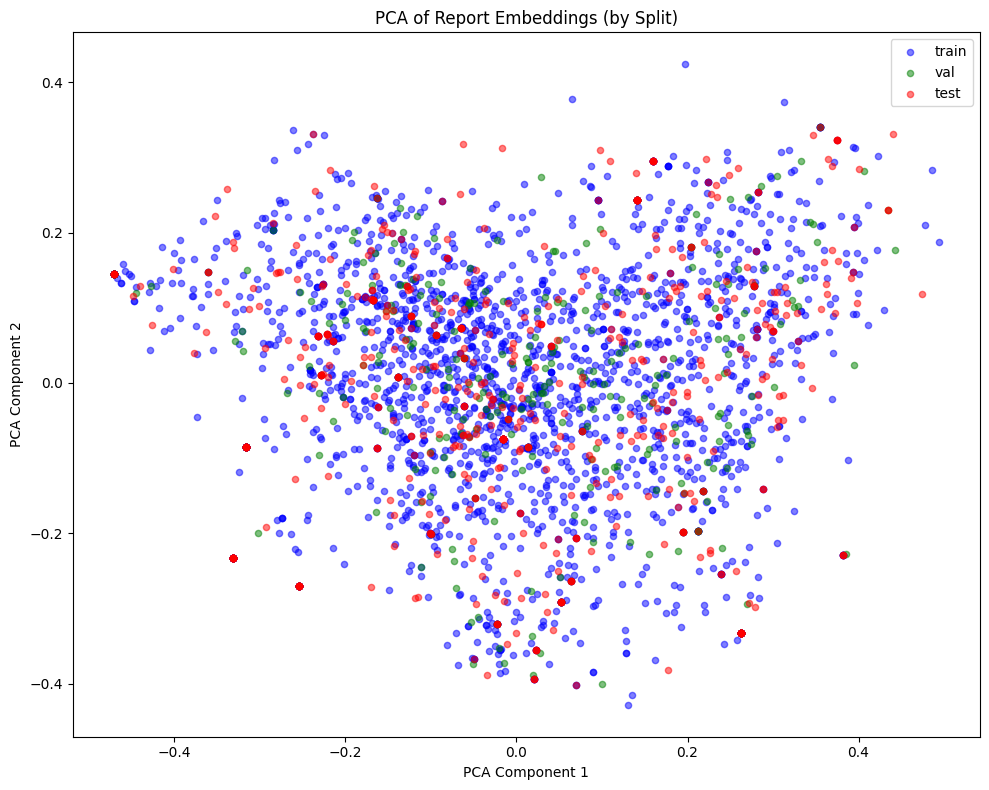

In [26]:
# Visualize PCA by split
plt.figure(figsize=(10, 8))

split_colors = {'train': 'blue', 'val': 'green', 'test': 'red'}

for split in ['train', 'val', 'test']:
    mask = df['split'] == split
    plt.scatter(
        embeddings_pca_2d[mask, 0], 
        embeddings_pca_2d[mask, 1], 
        c=split_colors[split], 
        label=split, 
        alpha=0.5, 
        s=20
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Report Embeddings (by Split)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. t-SNE Visualization

In [27]:
# Apply t-SNE for better visualization
# Use PCA-reduced embeddings for faster t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings_pca)

print("t-SNE completed!")

t-SNE completed!


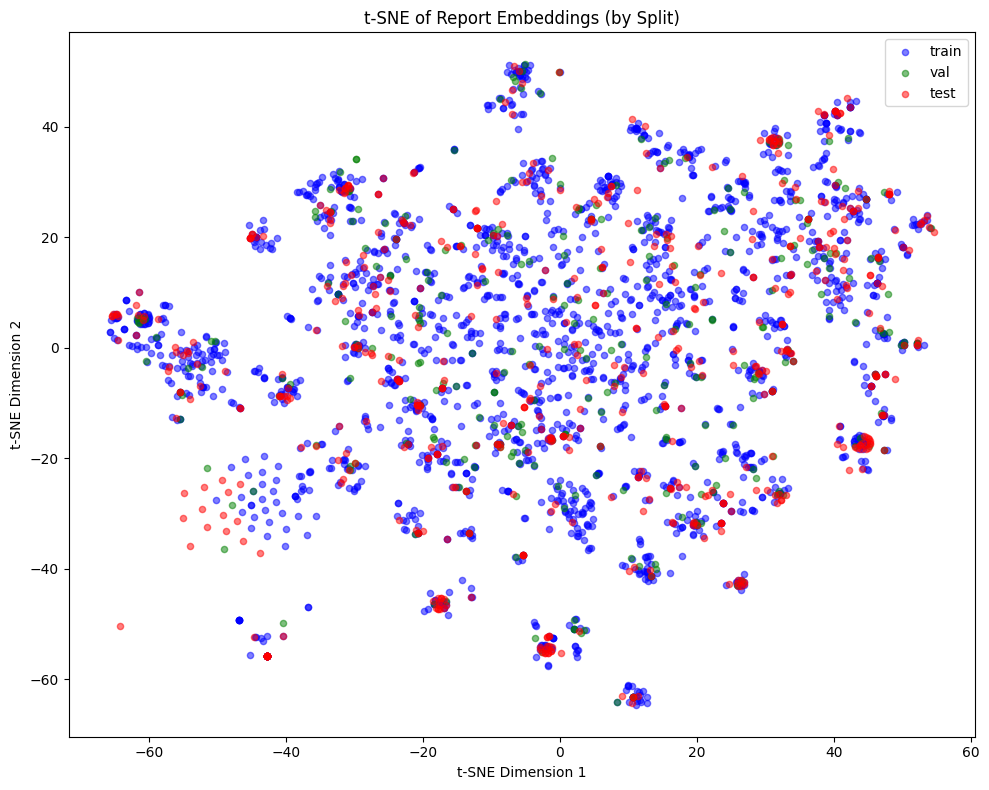

In [28]:
# Visualize t-SNE by split
plt.figure(figsize=(10, 8))

for split in ['train', 'val', 'test']:
    mask = df['split'] == split
    plt.scatter(
        embeddings_tsne[mask, 0], 
        embeddings_tsne[mask, 1], 
        c=split_colors[split], 
        label=split, 
        alpha=0.5, 
        s=20
    )

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE of Report Embeddings (by Split)')
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Phần lớn 3 màu trộn lẫn hoàn toàn vào nhau -> không có distribution shift giữa các split nên khi model train trên *train set* có thể gặp lại dữ liệu trên *test set*.
- Có nhiều cụm nhỏ được tách biệt rải rác như ở góc dưới bên trái -> Report trong dataset không đồng nhất, có thể có nhiều mô tả khác nhau.
- Không có sự tách biệt thành 2 khối lớn -> Report normal và abnormal có thể chia sẽ nhiều  từ vựng chung.
- Có 1 vài outliers như [-50;-60],.. Có thể do report dài, có cấu trúc khác thường hoặc khá hiếm.
- Tỉ trọng ở trung tâm khá cao 


In [40]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)

pred = iso.fit_predict(embeddings_pca)

outlier_indices = np.where(pred == -1)[0]

for idx in outlier_indices[:20]:
    print("\nOUTLIER REPORT:")
    print(df['report'].iloc[idx])


OUTLIER REPORT:
The tracheostomy tube is in stable position. Right subclavian catheter tip is in the lower SVC. The left upper extremity PICC tip is in the mid SVC. Surgical XXXX overlie the soft tissues of the neck. The lungs are clear. Heart size is normal. No pneumothorax.

OUTLIER REPORT:
Heart XXXX, mediastinum, XXXX, bony structures are unremarkable. Possible subtle increased opacity in right apex versus technique. Otherwise no significant interval change compared to prior study

OUTLIER REPORT:
No stable cardiomegaly, without focal consolidation, pneumothorax, or pleural effusion. Stable right basilar calcified granuloma. No acute osseous abnormality identified.

OUTLIER REPORT:
Cardiomegaly and tortuous calcified thoracic aorta are unchanged. Normal pulmonary vascularity. Minimal streaky bibasilar opacities. Blunted left costophrenic XXXX. Bony demineralization. Degenerative changes of the spine. Verterbroplasty change near the thoracolumbar junction. Upper abdominal surgical 

## 6. Clustering Analysis

Finding optimal number of clusters...
k=2: silhouette=0.0908
k=3: silhouette=0.0834
k=4: silhouette=0.0878
k=5: silhouette=0.0913
k=6: silhouette=0.0973
k=7: silhouette=0.1049
k=8: silhouette=0.1092
k=9: silhouette=0.1137
k=10: silhouette=0.1102
k=11: silhouette=0.1143
k=12: silhouette=0.1185
k=13: silhouette=0.1014
k=14: silhouette=0.1235


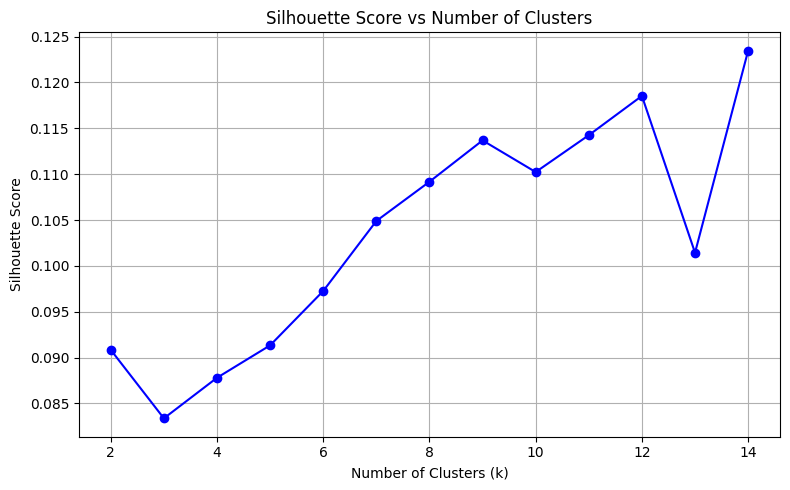


Optimal number of clusters: 14


In [30]:
# Find optimal number of clusters using silhouette score
silhouette_scores = []
k_range = range(2, 15)

print("Finding optimal number of clusters...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings_pca)
    score = silhouette_score(embeddings_pca, cluster_labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_k}")

In [31]:
# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_pca)

df['cluster'] = cluster_labels

print(f"Cluster distribution:")
print(df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     291
1     254
2     287
3     162
4     150
5     359
6     257
7     423
8      51
9     157
10     59
11    108
12    101
13    296
Name: count, dtype: int64


## 7. Cluster Visualization

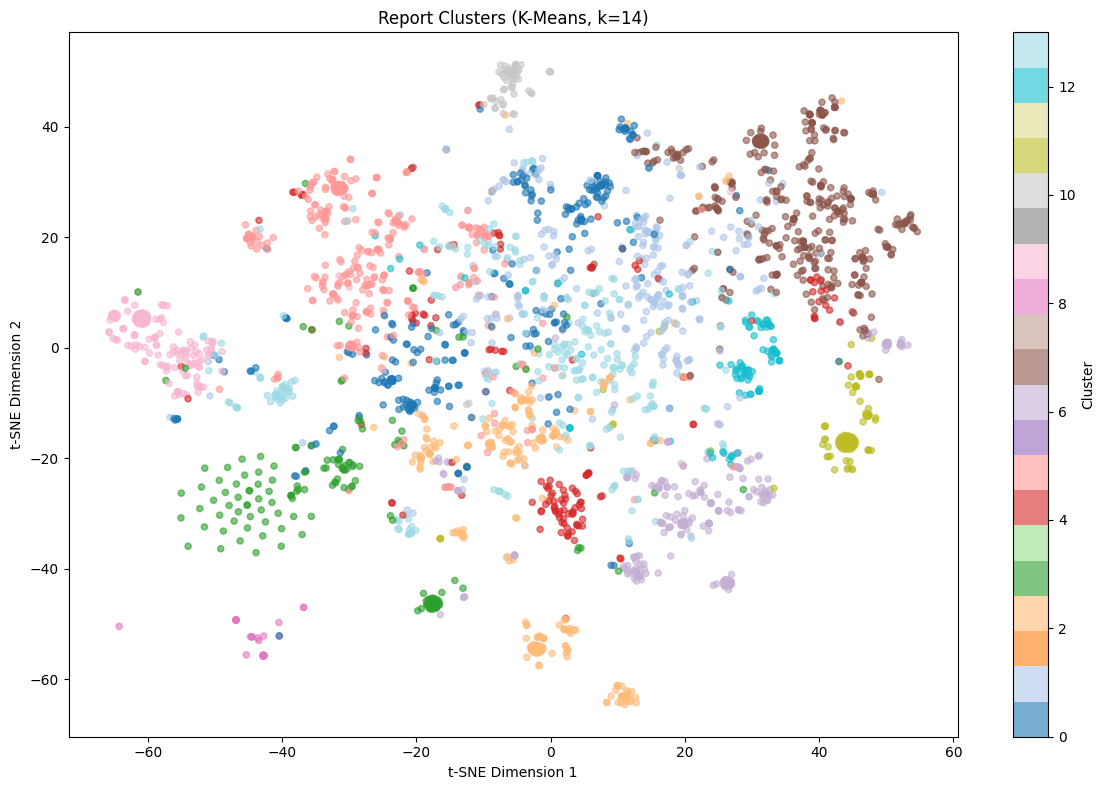

In [32]:
# Visualize clusters with t-SNE
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    embeddings_tsne[:, 0], 
    embeddings_tsne[:, 1], 
    c=cluster_labels, 
    cmap='tab20', 
    alpha=0.6, 
    s=20
)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title(f'Report Clusters (K-Means, k={optimal_k})')
plt.tight_layout()
plt.show()

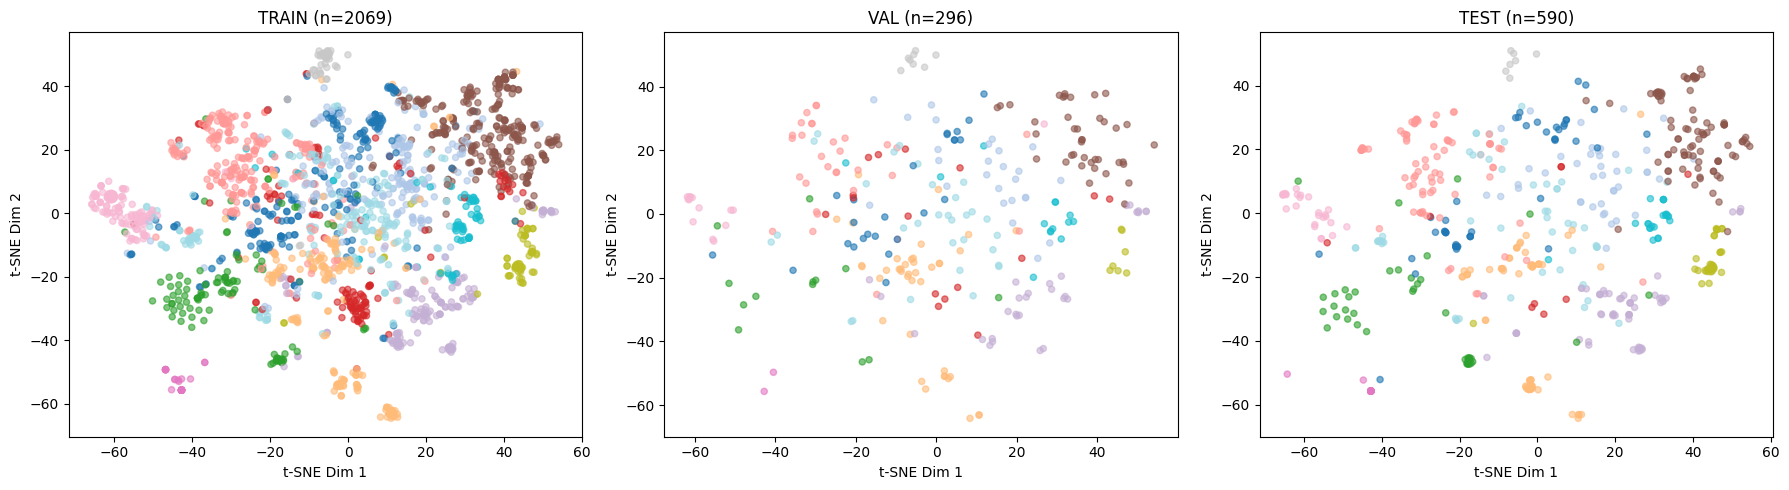

In [33]:
# Visualize clusters by split
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(['train', 'val', 'test']):
    mask = df['split'] == split
    axes[i].scatter(
        embeddings_tsne[mask, 0], 
        embeddings_tsne[mask, 1], 
        c=cluster_labels[mask], 
        cmap='tab20', 
        alpha=0.6, 
        s=20
    )
    axes[i].set_title(f'{split.upper()} (n={mask.sum()})')
    axes[i].set_xlabel('t-SNE Dim 1')
    axes[i].set_ylabel('t-SNE Dim 2')

plt.tight_layout()
plt.show()

## 8. Cluster Analysis

In [34]:
# Analyze cluster contents
print("="*60)
print("CLUSTER ANALYSIS")
print("="*60)

# Sample reports from each cluster
for cluster_id in range(optimal_k):
    cluster_reports = df[df['cluster'] == cluster_id]['report']
    print(f"\n📌 Cluster {cluster_id} ({len(cluster_reports)} reports):")
    print("-" * 50)
    
    # Show 2 sample reports
    for j, report in enumerate(cluster_reports.sample(min(2, len(cluster_reports)))):
        print(f"   Sample {j+1}: {report[:150]}...")
    print()

CLUSTER ANALYSIS

📌 Cluster 0 (291 reports):
--------------------------------------------------
   Sample 1: There is a left basilar airspace opacity. Right basilar atelectasis. The heart size and mediastinal silhouette are within normal limits for contour. N...
   Sample 2: Frontal and lateral views of the chest with overlying external cardiac monitor leads show normal size and configuration of the cardiac silhouette. The...


📌 Cluster 1 (254 reports):
--------------------------------------------------
   Sample 1: XXXX sternotomy XXXX appear intact. Surgical clips overlying the mediastinum. Mitral valve replacement seen. Low lung volumes. The interstitial markin...
   Sample 2: Stable scarring near the right lung apex along the lateral aspect. Lungs are otherwise clear. No pleural effusions or pneumothoraces. Heart and medias...


📌 Cluster 2 (287 reports):
--------------------------------------------------
   Sample 1: Heart size and mediastinal contour are normal. Pulmonary vascul

CLUSTER ANALYSIS

📌 Cluster 0 (291 reports):
--------------------------------------------------

Sample 1
Report: The XXXX examination consists of supine and crosstable lateral radiographs of the chest. External monitor leads XXXX the thorax. The cardiomediastinal contours are within normal limits. Pulmonary vasc...
Images: ['CXR380_IM-1911/0.png', 'CXR380_IM-1911/1.png']


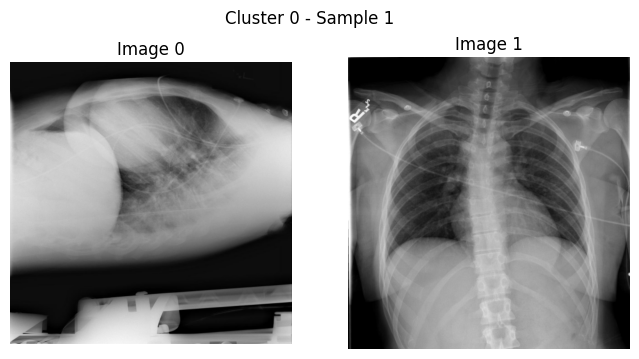


Sample 2
Report: The heart is normal in size and contour. There is no mediastinal widening. No focal airspace disease. No large pleural effusion or pneumothorax. The XXXX are intact....
Images: ['CXR2470_IM-1001/0.png', 'CXR2470_IM-1001/1.png']


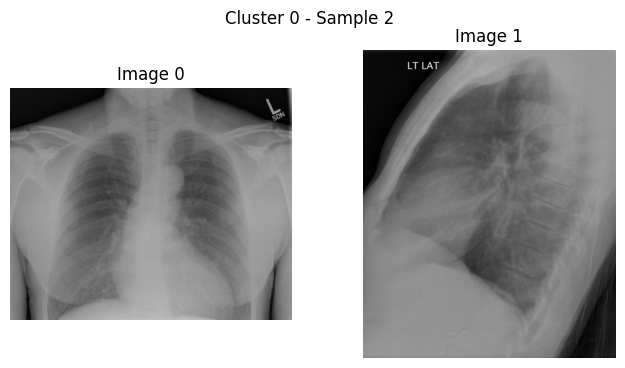



📌 Cluster 1 (254 reports):
--------------------------------------------------

Sample 1
Report: 2 images. The cardiac silhouette is enlarged. Thoracic aortic atherosclerotic calcifications are present. There are finding status post sternotomy and CABG. XXXX atelectasis or scar is noted within th...
Images: ['CXR1234_IM-0157/0.png', 'CXR1234_IM-0157/1.png']


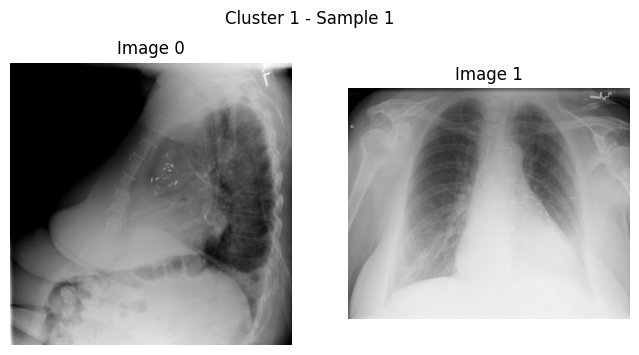


Sample 2
Report: There is S-shaped thoracolumbar scoliosis. There are T-spine osteophytes. XXXX opacity in the left lower lobe XXXX represents atelectasis or scarring. There is no pneumothorax. There is no large pleur...
Images: ['CXR535_IM-2142/0.png', 'CXR535_IM-2142/1.png']


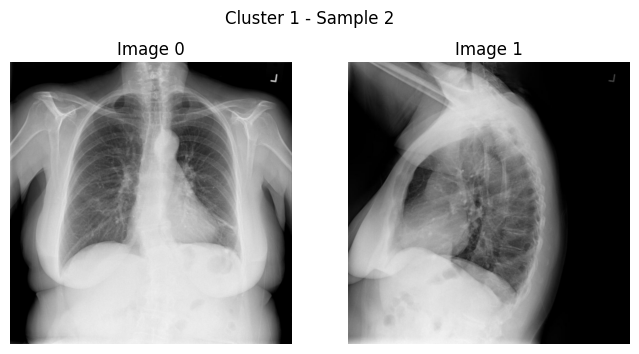



📌 Cluster 2 (287 reports):
--------------------------------------------------

Sample 1
Report: Cardiac and mediastinal contours are within normal limits. The lungs are clear. Left axillary surgical clips. Bony structures are intact....
Images: ['CXR33_IM-1576/0.png', 'CXR33_IM-1576/1.png']


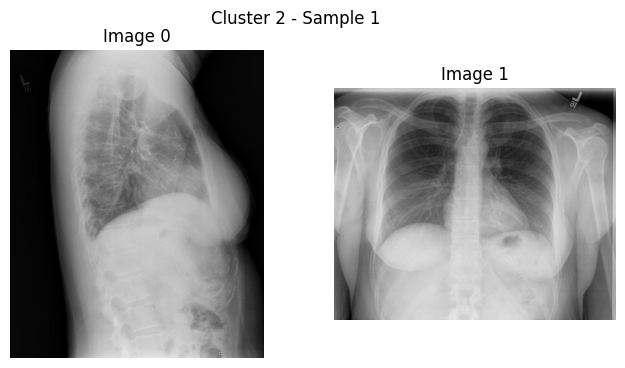


Sample 2
Report: Cardiac and mediastinal contours are within normal limits. The lungs are clear. Bony structures are intact....
Images: ['CXR3385_IM-1632/0.png', 'CXR3385_IM-1632/1.png']


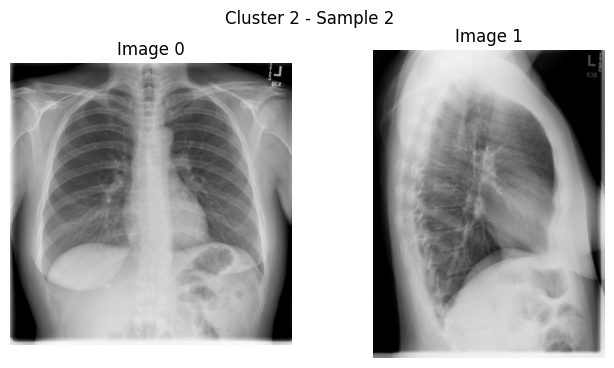



📌 Cluster 3 (162 reports):
--------------------------------------------------

Sample 1
Report: Lungs are hyperexpanded. No infiltrates or masses in the lungs. Heart size normal. No change calcified left hilar XXXX and left small granuloma....
Images: ['CXR3410_IM-1648/0.png', 'CXR3410_IM-1648/1.png']


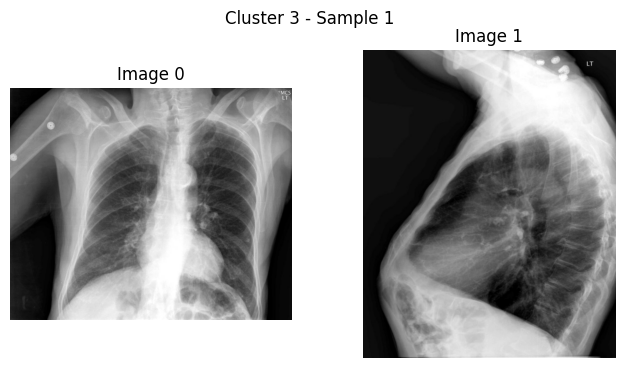


Sample 2
Report: The heart is large. Lung volumes are XXXX. XXXX opacity persists in the right midlung. No focal infiltrates....
Images: ['CXR1595_IM-0386/0.png', 'CXR1595_IM-0386/1.png']


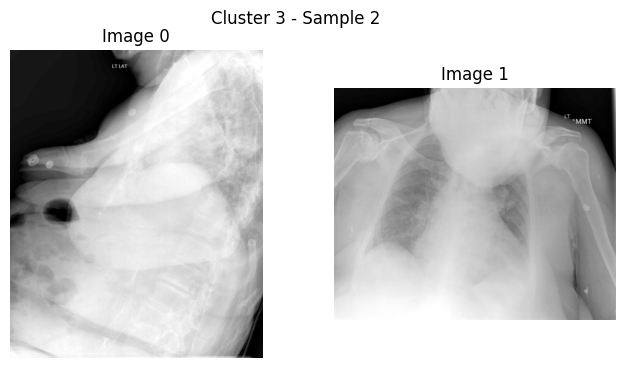



📌 Cluster 4 (150 reports):
--------------------------------------------------

Sample 1
Report: The heart size and pulmonary vascularity appear within normal limits. The lungs are free of focal airspace disease. No pleural effusion or pneumothorax is seen. Calcified granuloma are noted. A few XX...
Images: ['CXR952_IM-2447/0.png', 'CXR952_IM-2447/1.png']


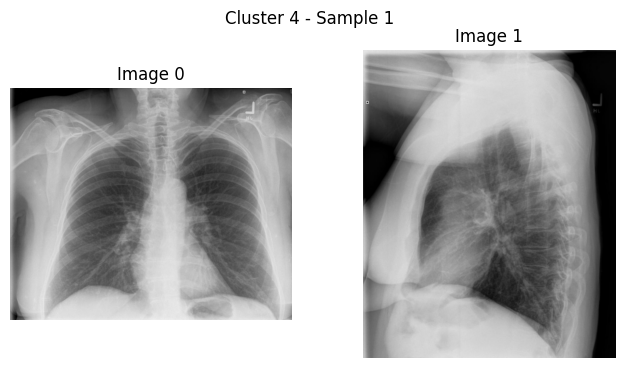


Sample 2
Report: Stable calcified hilar XXXX and granulomas. Lungs are clear bilaterally. There is no focal consolidation, pleural effusion, or pneumothoraces. Cardiomediastinal silhouette is within normal limits. XXX...
Images: ['CXR2144_IM-0765/0.png', 'CXR2144_IM-0765/1.png']


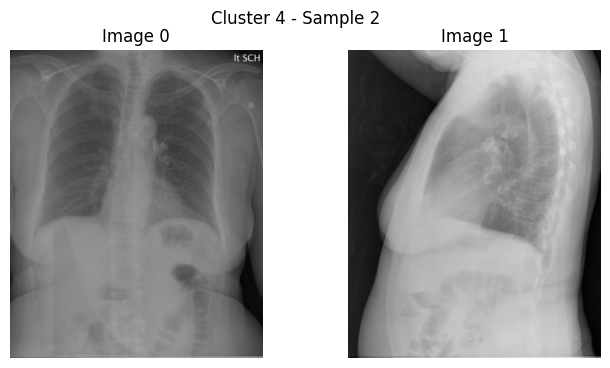



📌 Cluster 5 (359 reports):
--------------------------------------------------

Sample 1
Report: Heart size and pulmonary vascularity appear within normal limits. Innumerable bilateral lung nodules are present. These are seen diffusely throughout both lungs. No superimposed focal airspace disease...
Images: ['CXR1058_IM-0041/0.png', 'CXR1058_IM-0041/1.png']


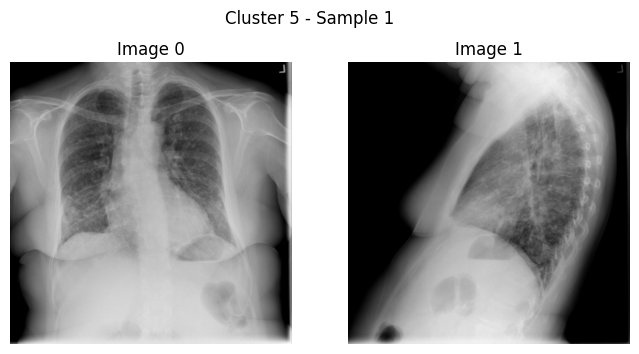


Sample 2
Report: Heart size within normal limits. No focal alveolar consolidation, no definite pleural effusion seen. No typical findings of pulmonary edema. No pneumothorax....
Images: ['CXR968_IM-2458/0.png', 'CXR968_IM-2458/1.png']


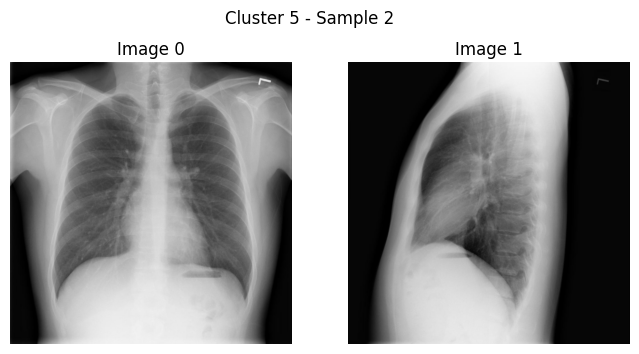



📌 Cluster 6 (257 reports):
--------------------------------------------------

Sample 1
Report: Lungs are clear. No pleural effusions or pneumothoraces. heart and mediastinum are stable with normal sized heart. Degenerative changes in the spine....
Images: ['CXR617_IM-2200/0.png', 'CXR617_IM-2200/1.png']


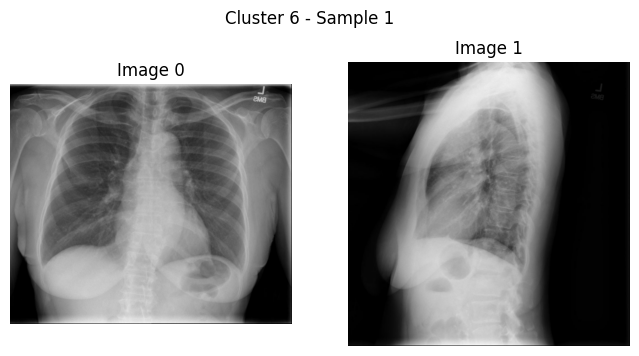


Sample 2
Report: The lungs are clear. No pleural effusion or pneumothorax is identified. The heart and mediastinum are normal. The skeletal structures and soft tissues are normal....
Images: ['CXR2663_IM-1144/0.png', 'CXR2663_IM-1144/1.png']


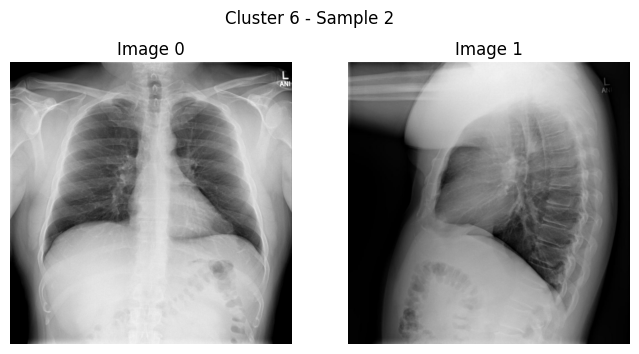



📌 Cluster 7 (423 reports):
--------------------------------------------------

Sample 1
Report: PA and lateral views the chest were obtained. The cardiomediastinal silhouette is normal in size and configuration. The lungs are well aerated. No pneumothorax, pleural effusion, or focal air space co...
Images: ['CXR3253_IM-1542/0.png', 'CXR3253_IM-1542/1.png']


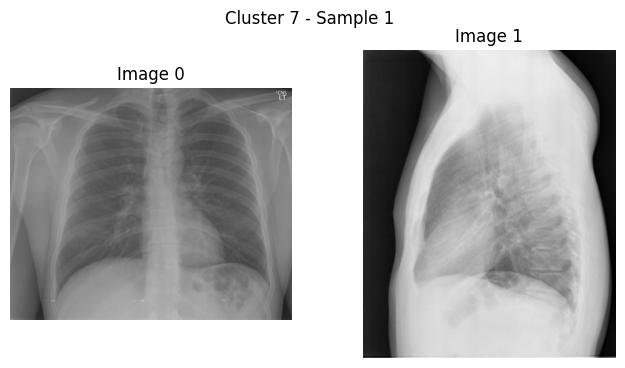


Sample 2
Report: Coronary artery stents visualized. The cardiomediastinal silhouette is within normal limits for size and contour. The lungs are normally inflated without evidence of focal airspace disease, pleural ef...
Images: ['CXR1195_IM-0131/0.png', 'CXR1195_IM-0131/1.png']


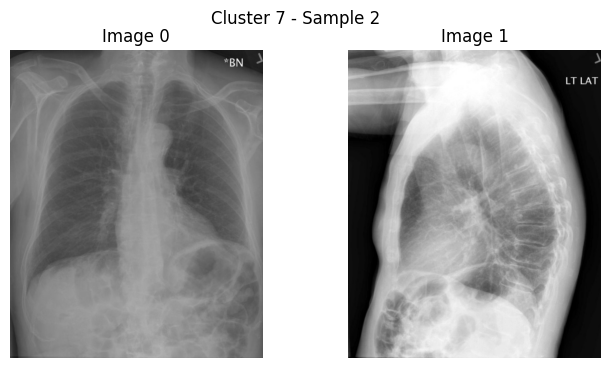



📌 Cluster 8 (51 reports):
--------------------------------------------------

Sample 1
Report: The heart and lungs have XXXX XXXX in the interval. Both lungs are clear and expanded. Heart and mediastinum normal....
Images: ['CXR1077_IM-0054/0.png', 'CXR1077_IM-0054/1.png']


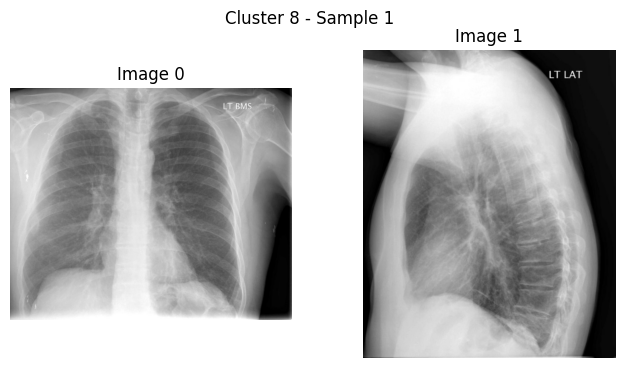


Sample 2
Report: The heart and lungs have XXXX XXXX in the interval. Both lungs are clear and expanded. No change in the small calcified right upper lobe nodule. Heart and mediastinum normal....
Images: ['CXR1022_IM-0017/0.png', 'CXR1022_IM-0017/1.png']


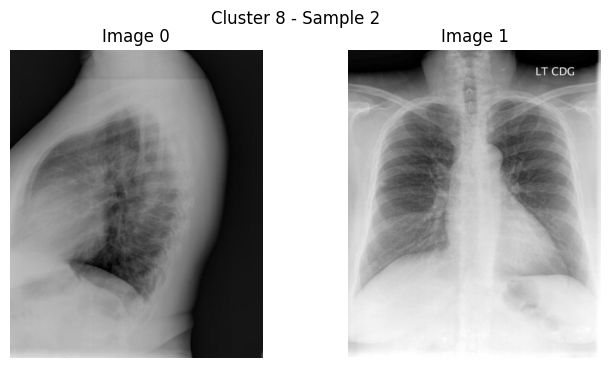



📌 Cluster 9 (157 reports):
--------------------------------------------------

Sample 1
Report: The heart is normal in size. The mediastinum is unremarkable. Mild emphysematous changes are noted. The lungs are otherwise clear....
Images: ['CXR3297_IM-1575/0.png', 'CXR3297_IM-1575/1.png']


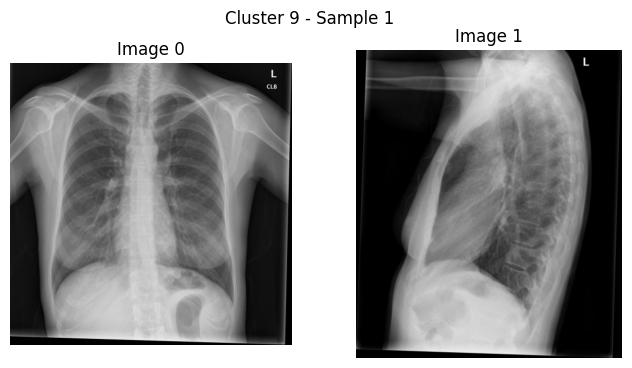


Sample 2
Report: The heart is normal in size. The mediastinum is stable with tortuous aorta. There are chronic changes particularly noted in the lung apices. The XXXX are mildly prominent but stable. No acute infiltra...
Images: ['CXR1242_IM-0164/0.png', 'CXR1242_IM-0164/1.png']


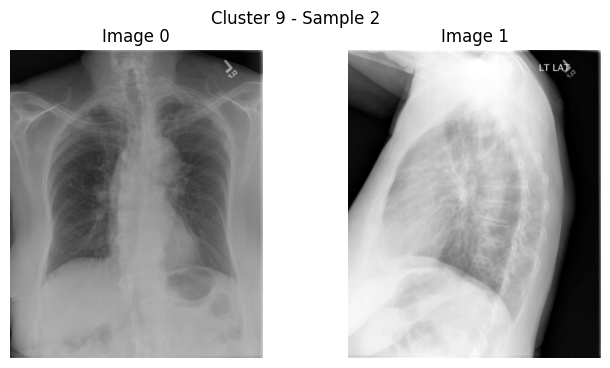



📌 Cluster 10 (59 reports):
--------------------------------------------------

Sample 1
Report: Heart size within normal limits. Trachea is midline. The lung volumes are is somewhat low. Both lungs are otherwise clear bilaterally. No pleural effusion. No pulmonary nodules visualized....
Images: ['CXR3229_IM-1526/0.png', 'CXR3229_IM-1526/1.png']


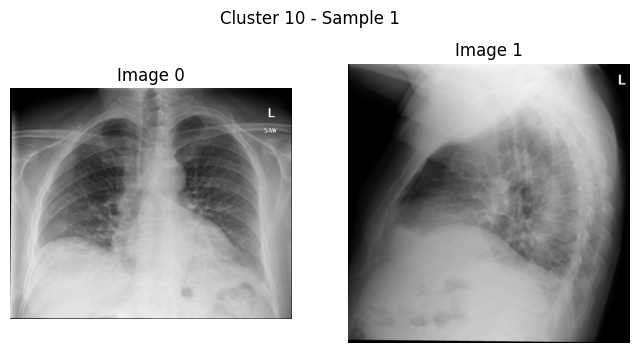


Sample 2
Report: The trachea is midline. The cardiomediastinal silhouette is normal. The lungs are clear, without evidence of acute infiltrate or effusion. There is no pneumothorax. The visualized bony structures reve...
Images: ['CXR2740_IM-1195/0.png', 'CXR2740_IM-1195/1.png']


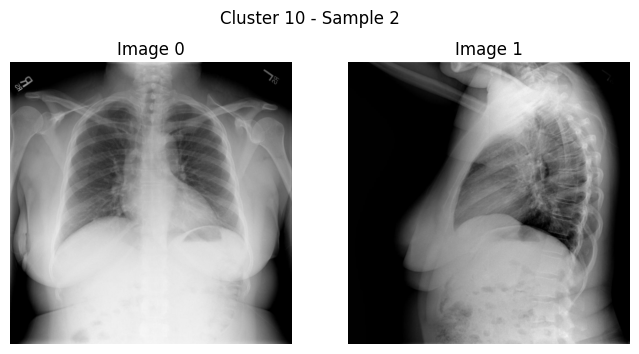



📌 Cluster 11 (108 reports):
--------------------------------------------------

Sample 1
Report: The lungs are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion.. Cardio mediastinal silhouette is unremarkable. Visualized osseous structures of t...
Images: ['CXR1796_IM-0517/0.png', 'CXR1796_IM-0517/1.png']


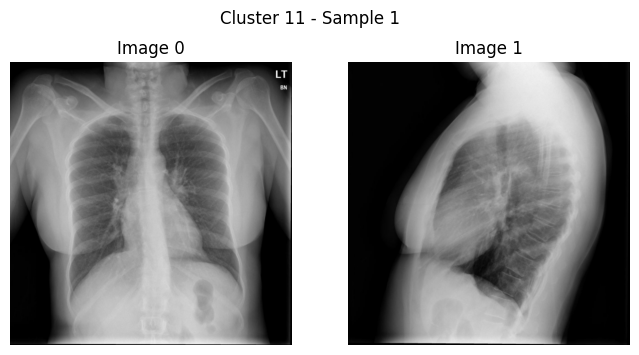


Sample 2
Report: The lungs demonstrate low lung volumes but are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion.. Mild streaky opacities in the left upper lobe on...
Images: ['CXR1085_IM-0059/0.png', 'CXR1085_IM-0059/1.png']


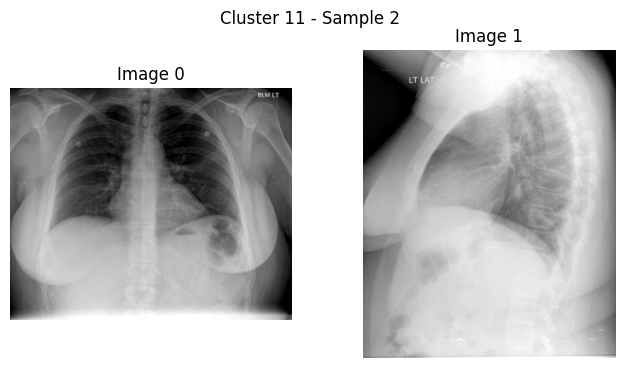



📌 Cluster 12 (101 reports):
--------------------------------------------------

Sample 1
Report: The cardiac silhouette is at the upper limits of normal for size. Patchy opacities are demonstrated in the left lung base. No focal pulmonary consolidation. No pneumothorax. Minimal degenerative chang...
Images: ['CXR2999_IM-1383-0001/0.png', 'CXR2999_IM-1383-0001/1.png']


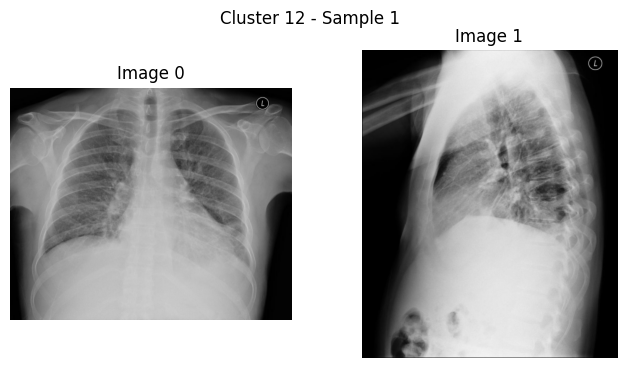


Sample 2
Report: No focal lung consolidation. Heart size and pulmonary vascularity are within normal limits. No pneumothorax or pleural effusion. Osseous structures are grossly intact....
Images: ['CXR3146_IM-1479/0.png', 'CXR3146_IM-1479/1.png']


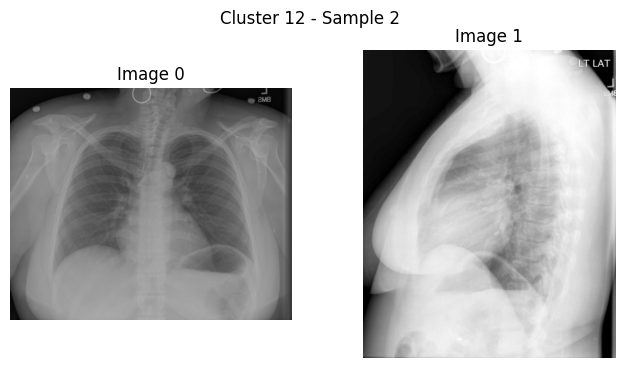



📌 Cluster 13 (296 reports):
--------------------------------------------------

Sample 1
Report: Redemonstration of colonic interposition overlying the mediastinum. There are increased bibasilar airspace opacities, left greater than right. No pneumothorax or large pleural effusion....
Images: ['CXR1244_IM-0166/0.png', 'CXR1244_IM-0166/1.png']


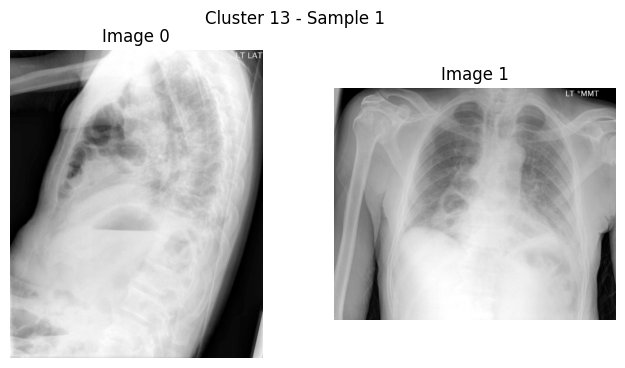


Sample 2
Report: The cardiac silhouette, upper mediastinum and pulmonary vasculature are within normal limits. There is no acute pulmonary consolidation, large effusion or pneumothorax. There is minimal left basilar a...
Images: ['CXR3753_IM-1877/0.png', 'CXR3753_IM-1877/1.png']


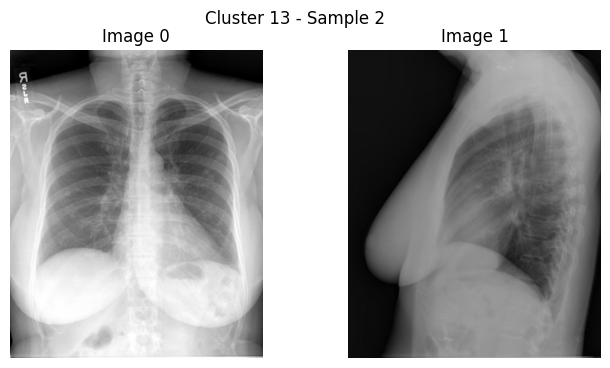

In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import os

print("="*60)
print("CLUSTER ANALYSIS")
print("="*60)

image_dir = "../../data/iu_xray/images/"  # Adjust this path to your actual image directory

for cluster_id in range(optimal_k):

    cluster_data = df[df['cluster'] == cluster_id]

    print(f"\n📌 Cluster {cluster_id} ({len(cluster_data)} reports):")
    print("-" * 50)

    samples = cluster_data.sample(min(2, len(cluster_data)))

    for j, (_, row) in enumerate(samples.iterrows()):

        report = row['report']
        img_paths = row['image_path']   # đây là LIST

        print(f"\nSample {j+1}")
        print(f"Report: {report[:200]}...")
        print(f"Images: {img_paths}")

        # vẽ các ảnh
        fig, axes = plt.subplots(1, len(img_paths), figsize=(8,4))

        if len(img_paths) == 1:
            axes = [axes]

        for i, img_path in enumerate(img_paths):

            full_path = os.path.join(image_dir, img_path)  # thư mục ảnh

            try:
                img = Image.open(full_path)

                axes[i].imshow(img, cmap='gray')
                axes[i].set_title(f"Image {i}")
                axes[i].axis("off")

            except Exception as e:
                print("Cannot load image:", e)

        plt.suptitle(f"Cluster {cluster_id} - Sample {j+1}")
        plt.show()

    print()

In [35]:
# Analyze disease keywords in each cluster
diseases = [
    "atelectasis", "cardiomegaly", "consolidation", "edema",
    "effusion", "emphysema", "fibrosis", "hernia", "infiltration",
    "mass", "nodule", "pleural", "pneumonia", "pneumothorax"
]

# Create disease matrix for clusters
cluster_disease_matrix = []

for cluster_id in range(optimal_k):
    cluster_reports = df[df['cluster'] == cluster_id]['report']
    disease_counts = {}
    for d in diseases:
        count = cluster_reports.str.contains(d, case=False).sum()
        disease_counts[d] = count / len(cluster_reports) * 100 if len(cluster_reports) > 0 else 0
    cluster_disease_matrix.append(disease_counts)

cluster_disease_df = pd.DataFrame(cluster_disease_matrix)
cluster_disease_df.index.name = 'Cluster'

print("Disease Distribution by Cluster (%):")
print(cluster_disease_df.round(2).to_string())

Disease Distribution by Cluster (%):
         atelectasis  cardiomegaly  consolidation  edema  effusion  emphysema  fibrosis  hernia  infiltration   mass  nodule  pleural  pneumonia  pneumothorax
Cluster                                                                                                                                                       
0              11.00          1.37          21.99   3.09     76.98       3.78      0.69    1.03           0.0   9.62   13.06    73.54       1.03         74.57
1              17.72         31.10          43.70   9.45     77.56       1.57      0.39    2.36           0.0   1.97    2.36    69.69       1.18         76.77
2               3.83          0.70          37.63   0.70     62.72       1.39      0.00    0.35           0.0   1.74    4.18    60.28       0.00         56.45
3               2.47          0.00           4.94  27.78     41.36       0.00      0.00    1.85           0.0  31.48   30.25    11.11      27.16         35.19
4        

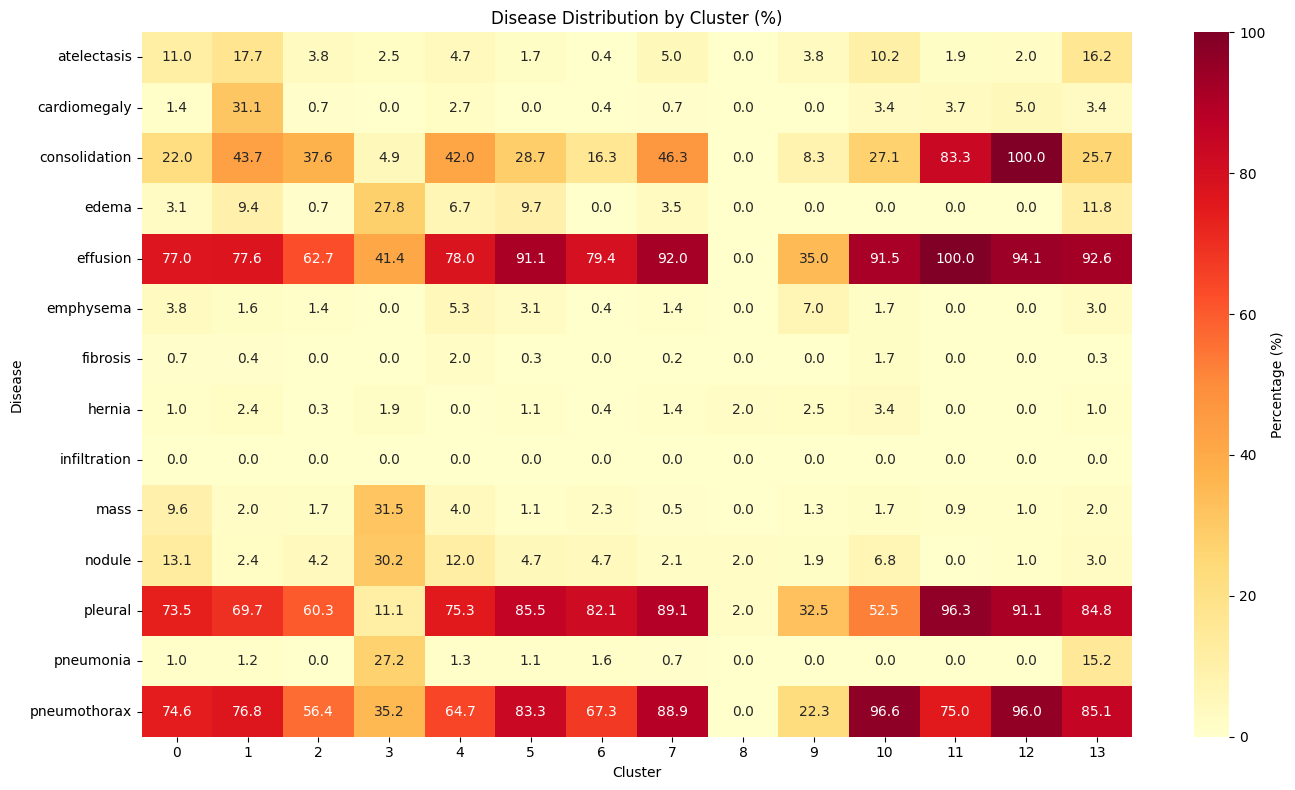

In [36]:
# Heatmap of disease distribution by cluster
plt.figure(figsize=(14, 8))

sns.heatmap(
    cluster_disease_df.T, 
    cmap='YlOrRd', 
    annot=True, 
    fmt='.1f',
    cbar_kws={'label': 'Percentage (%)'}
)

plt.title('Disease Distribution by Cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Disease')
plt.tight_layout()
plt.show()

## 9. Report Length Analysis by Cluster

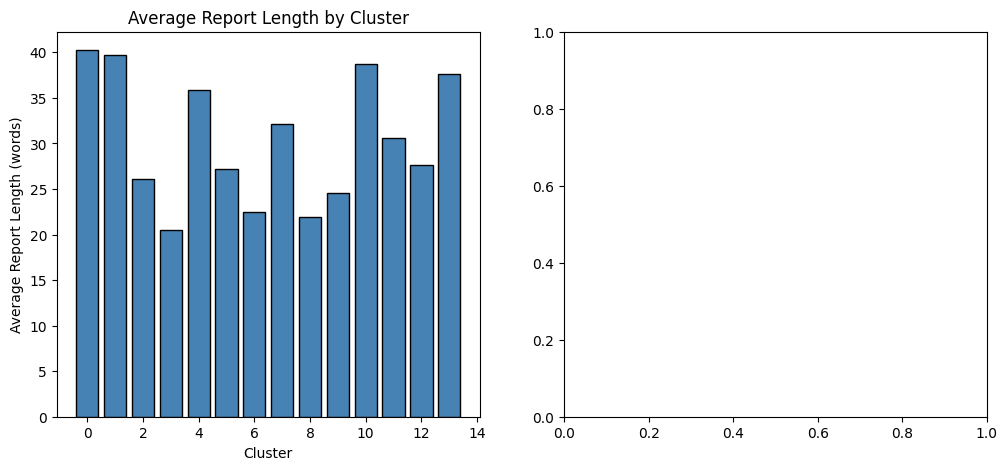

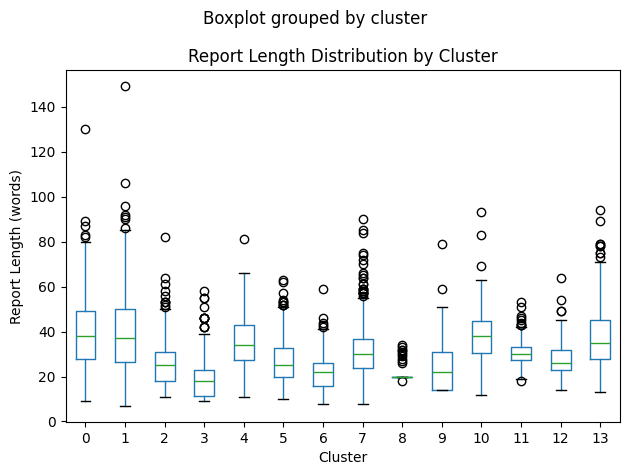


Report Length Statistics by Cluster:
         count       mean        std   min    25%   50%    75%    max
cluster                                                              
0        291.0  40.243986  15.639217   9.0  28.00  38.0  49.00  130.0
1        254.0  39.755906  18.889618   7.0  26.25  37.0  50.00  149.0
2        287.0  26.045296  10.638762  11.0  18.00  25.0  31.00   82.0
3        162.0  20.524691  10.748509   9.0  11.25  18.0  23.00   58.0
4        150.0  35.853333  12.590817  11.0  27.25  34.0  43.00   81.0
5        359.0  27.194986  10.104531  10.0  20.00  25.0  32.50   63.0
6        257.0  22.521401   7.807281   8.0  16.00  22.0  26.00   59.0
7        423.0  32.127660  11.982719   8.0  24.00  30.0  36.50   90.0
8         51.0  21.960784   4.270648  18.0  20.00  20.0  20.00   34.0
9        157.0  24.515924  11.045712  14.0  14.00  22.0  31.00   79.0
10        59.0  38.745763  15.525944  12.0  30.50  38.0  44.50   93.0
11       108.0  30.574074   6.742533  18.0  27.25  3

In [37]:
# Analyze report length by cluster
df['report_length'] = df['report'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cluster_lengths = df.groupby('cluster')['report_length'].mean()
plt.bar(cluster_lengths.index, cluster_lengths.values, color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Average Report Length (words)')
plt.title('Average Report Length by Cluster')

plt.subplot(1, 2, 2)
df.boxplot(column='report_length', by='cluster', grid=False)
plt.title('Report Length Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Report Length (words)')

plt.tight_layout()
plt.show()

print("\nReport Length Statistics by Cluster:")
print(df.groupby('cluster')['report_length'].describe())

## 10. Hierarchical Clustering

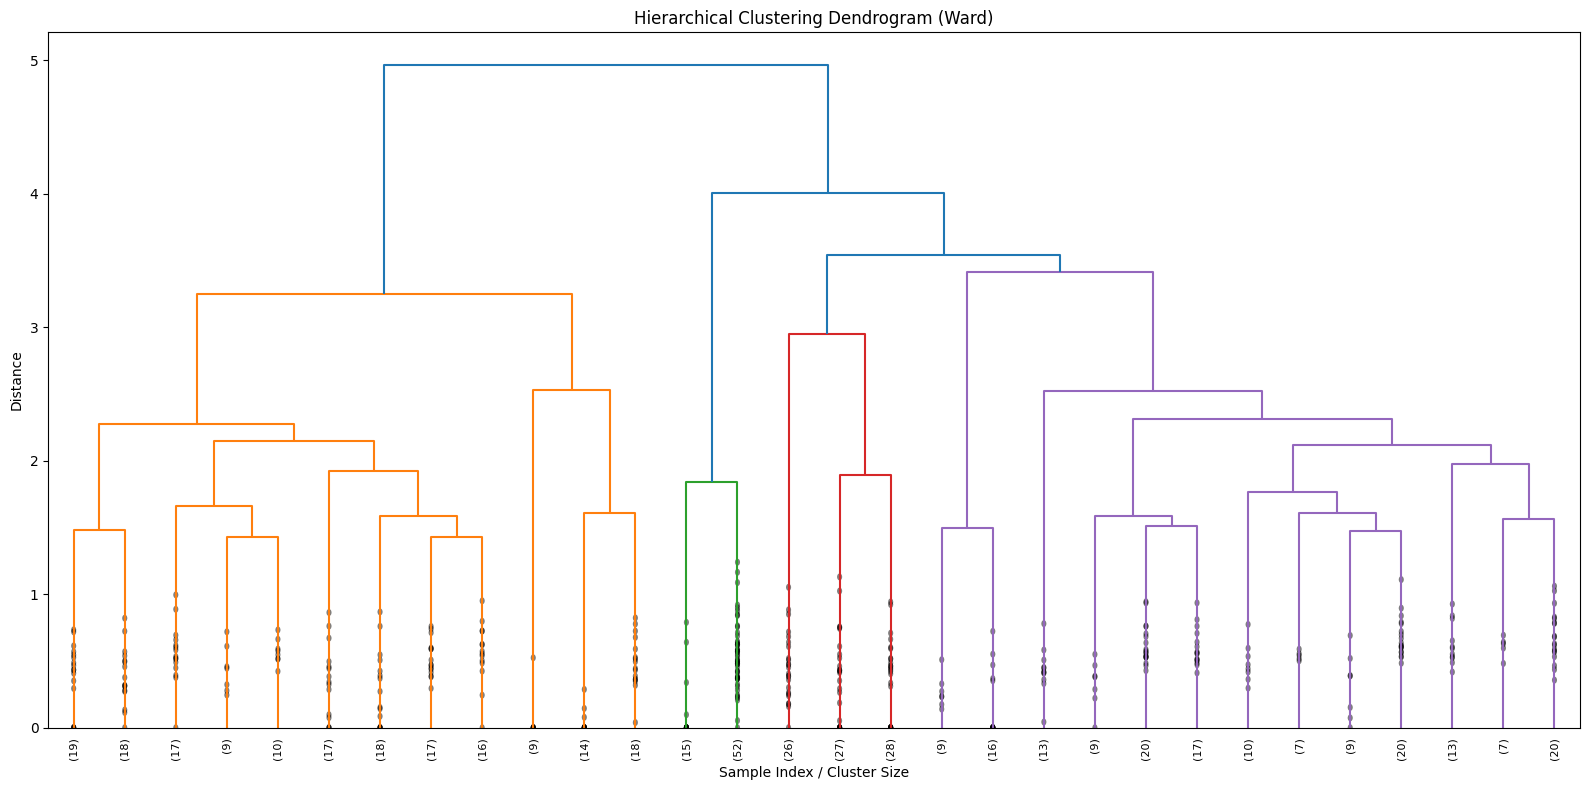

In [38]:
# Apply hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample for dendrogram (too many points will be slow)
sample_size = 500
sample_indices = np.random.choice(len(embeddings_pca), sample_size, replace=False)
sample_embeddings = embeddings_pca[sample_indices]

# Compute linkage
linkage_matrix = linkage(sample_embeddings, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(
    linkage_matrix, 
    truncate_mode='lastp',  
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## 11. Summary

In [39]:
print("="*60)
print("REPORT EMBEDDING CLUSTERING SUMMARY")
print("="*60)

print(f"\n📊 Dataset:")
print(f"   - Total reports: {len(df)}")
print(f"   - Embedding dimension: {embeddings.shape[1]}")

print(f"\n🔍 Clustering:")
print(f"   - Optimal clusters: {optimal_k}")
print(f"   - Best silhouette score: {max(silhouette_scores):.4f}")

print(f"\n📈 Cluster Sizes:")
for cluster_id in range(optimal_k):
    count = (cluster_labels == cluster_id).sum()
    pct = count / len(df) * 100
    print(f"   - Cluster {cluster_id}: {count} ({pct:.1f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

REPORT EMBEDDING CLUSTERING SUMMARY

📊 Dataset:
   - Total reports: 2955
   - Embedding dimension: 384

🔍 Clustering:
   - Optimal clusters: 14
   - Best silhouette score: 0.1235

📈 Cluster Sizes:
   - Cluster 0: 291 (9.8%)
   - Cluster 1: 254 (8.6%)
   - Cluster 2: 287 (9.7%)
   - Cluster 3: 162 (5.5%)
   - Cluster 4: 150 (5.1%)
   - Cluster 5: 359 (12.1%)
   - Cluster 6: 257 (8.7%)
   - Cluster 7: 423 (14.3%)
   - Cluster 8: 51 (1.7%)
   - Cluster 9: 157 (5.3%)
   - Cluster 10: 59 (2.0%)
   - Cluster 11: 108 (3.7%)
   - Cluster 12: 101 (3.4%)
   - Cluster 13: 296 (10.0%)

ANALYSIS COMPLETE!
